# Trace similarity and correlation analysis


Initialise the paths and the registers 

In [ ]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REG_NAMES = ['r0','r1','r2','r3','r4','r5','r6','r7',
             'r8','r9','r10','r11','r12','sp','lr']



Compute the hamming weight of the registers/row 

In [31]:
def hw(regs):
    total_weight = 0
    for r in regs:
        total_weight += int(r, 16).bit_count()
    return total_weight

Load the traces

In [ ]:
def load_trace(path):
    df = pd.read_csv(path)
    # Compute the sum of Hamming weights across all registers for each instruction
    return df[REG_NAMES].apply(hw, axis=1).values

trace_path = {}
traces = {}

ind = 0
while True:
    path = f'output_decapsulation_parallel/TRACE_{ind}/trace_{ind}.csv'
    if not os.path.exists(path):
        break 
    trace_path[ind] = path
    traces[ind] = load_trace(path)
    ind += 1

print(f"The number of traces is: {len(traces)}")

# put the value of the traces in a list 
all_traces = list(traces.values())
min_len = min(len(t) for t in all_traces)
X = np.array([t[:min_len] for t in all_traces])

print(f"Minimum length of a trace is {min_len}")

Compute cross correlation between 2 traces

In [ ]:
def cross_correlation(first, second):
    # Compute the normalized cross-correlation between two traces
    n = min(len(first), len(second))
    return np.correlate(first - first.mean(), second - second.mean(), mode='full')[n-1:] / (first.std() * second.std() * n)


Plot HW for all the traces:

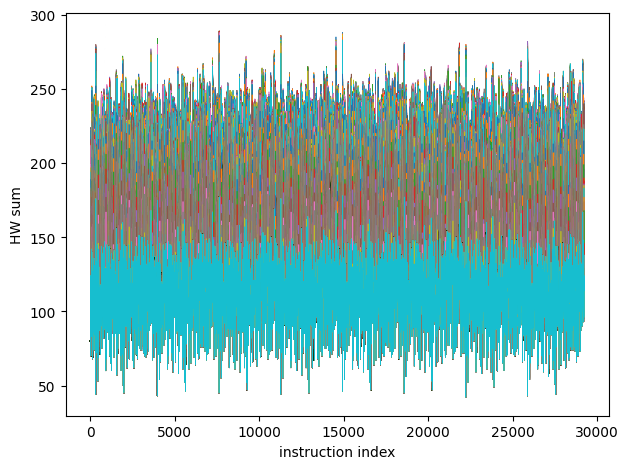

In [ ]:
fig, ax1 = plt.subplots()
for i in range(len(traces)):
    ax1.plot(traces[i], lw=0.5)

ax1.set_ylabel("HW sum")
ax1.set_xlabel("instruction index")
plt.tight_layout()
plt.show()

Calculate mean, variance, standard deviation

In [ ]:
mean_trace = np.mean(X, axis=0)
var_trace = np.var(X, axis=0)
std_trace = np.std(X, axis=0)

Plot mean

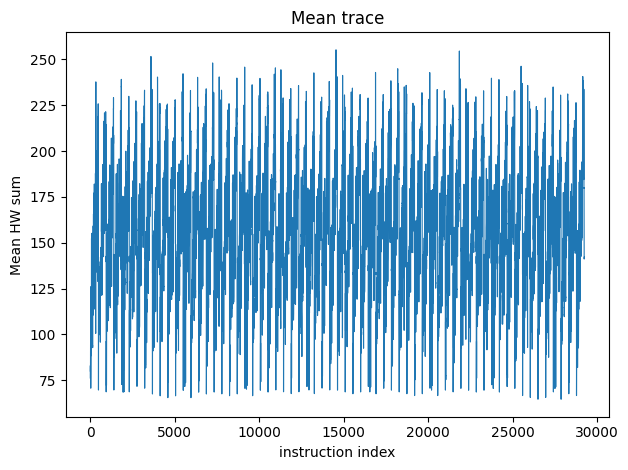

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(mean_trace, lw=0.8)
ax1.set_title("Mean trace")
ax1.set_ylabel("Mean HW sum")
ax1.set_xlabel("instruction index")
plt.tight_layout()
plt.show()

Plot variance 

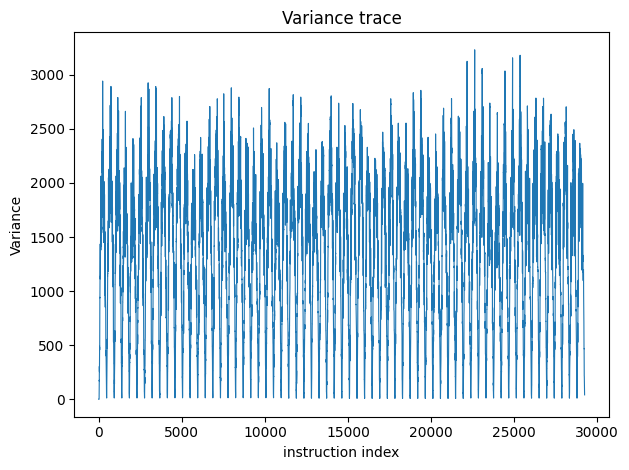

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(var_trace, lw=0.8)
ax1.set_title("Variance trace")
ax1.set_ylabel("Variance")
ax1.set_xlabel("instruction index")
plt.tight_layout()
plt.show()

Plot standard deviation

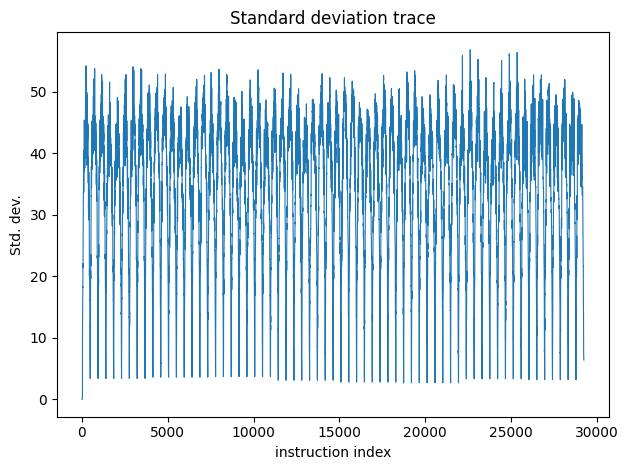

In [ ]:
fig, ax1 = plt.subplots()
ax1.plot(std_trace, lw=0.8)
ax1.set_title("Standard deviation trace")
ax1.set_ylabel("Std. dev.")
ax1.set_xlabel("instruction index")
plt.tight_layout()
plt.show()

Choose 2 traces that you want to compare: 

In [ ]:
index1, index2 = 0, 640
first_trace, second_trace = traces[index1], traces[index2]

n = min(len(first_trace), len(second_trace))
first_trace = first_trace[:n]
second_trace = second_trace[:n]

KeyError: 640

Plot the HW just for this 2 traces and calculat the maximum difference between them:

Maximum difference in HW sum: 119.0000


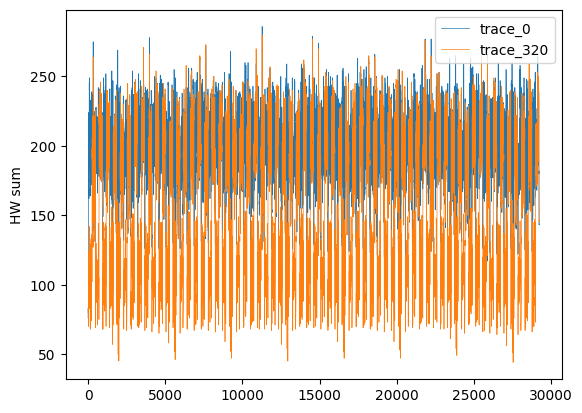

In [ ]:
fig, ax1 = plt.subplots()
diff = np.abs(first_trace - second_trace)
print(f"Maximum difference in HW sum: {diff.max():.4f}")

ax1.plot(first_trace, lw=0.5, label=f"trace_{index1}")
ax1.plot(second_trace, lw=0.5, label=f"trace_{index2}")
ax1.set_ylabel("HW sum")
ax1.legend()

Calculate the correlation and plot the cross-side correlation: 

Pearson r = 0.4099


Text(0.5, 0, 'instruction index')

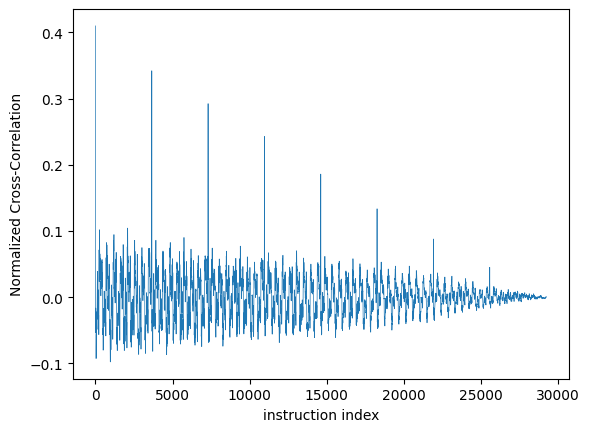

In [ ]:
fig, ax1 = plt.subplots()

corr = np.corrcoef(first_trace, second_trace)[0, 1]
print(f"Pearson r = {corr:.4f}")

ax1.plot(cross_correlation(first_trace, second_trace), lw=0.5)
ax1.set_ylabel("Normalized Cross-Correlation")
ax1.set_xlabel("instruction index")